# 1. Setup

In [2]:
import earthaccess  # needed to discover and download TEMPO data
import netCDF4 as nc  # needed to read TEMPO data
import numpy as np

import matplotlib.pyplot as plt  # needed to plot the resulting time series
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 2. Login

In [3]:
auth = earthaccess.login(persist=True)

# 3. Search for TEMPO granules

In [5]:
short_name = "TEMPO_NO2_L3"  # collection name to search for in the EarthData
version = "V03"

# Point of interest: NASA Langley Research Center, HamptonVA, USA
# latitude 37.1036 deg, longitude -76.3868 deg
# POI_lat = 37.1036
# POI_lon = -76.3868

# generic location, somewhere in the middle of the USA
POI_lat = 38.0
POI_lon = -96.0
date_start = "2024-09-01 00:00:00"
date_end = "2024-09-01 23:59:59"

In [6]:
POI_results = earthaccess.search_data(
    short_name=short_name,
    version=version,
    temporal=(date_start, date_end),
    point=(POI_lon, POI_lat),  # search by point of interest
)

print(len(POI_results))

18


In [7]:
dlat = 5.0  # deg
dlon = 6.0  # deg

bbox_results = earthaccess.search_data(
    short_name=short_name,
    version=version,
    temporal=(date_start, date_end),
    bounding_box=(
        POI_lon - dlon,
        POI_lat - dlat,
        POI_lon + dlon,
        POI_lat + dlat,
    ),  # search by bounding box
)

print(len(bbox_results))

18


# 4. Examine and download file results

In [8]:
POI_results[0]

Collection: {'ShortName': 'TEMPO_NO2_L3', 'Version': 'V03'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 57.02, 'Longitude': -163.84}, {'Latitude': 56.94, 'Longitude': -163.72}, {'Latitude': 56.1, 'Longitude': -158.9}, {'Latitude': 55.08, 'Longitude': -154.7}, {'Latitude': 53.88, 'Longitude': -150.84}, {'Latitude': 52.4, 'Longitude': -147.02}, {'Latitude': 50.66, 'Longitude': -143.38}, {'Latitude': 48.7, 'Longitude': -140.02}, {'Latitude': 46.62, 'Longitude': -137.06}, {'Latitude': 44.1, 'Longitude': -134.08}, {'Latitude': 41.38, 'Longitude': -131.42}, {'Latitude': 38.42, 'Longitude': -129.02}, {'Latitude': 35.62, 'Longitude': -127.12}, {'Latitude': 32.42, 'Longitude': -125.3}, {'Latitude': 29.02, 'Longitude': -123.7}, {'Latitude': 25.44, 'Longitude': -122.32}, {'Latitude': 21.64, 'Longitude': -121.14}, {'Latitude': 17.56, 'Longitude': -120.14}, {'Latitude': 17.26, 'Longitude': -102.38}, {'Latitude': 17.22, 'Longitude': -83.74001}, {'Latitude': 29.44, 'Longitude': -82.82}, {'Latitude': 34.42, 'Longitude': -82.28}, {'Latitude': 40.04, 'Longitude': -81.5}, {'Latitude': 48.12, 'Longitude': -79.92}, {'Latitude': 52.84, 'Longitude': -78.62}, {'Latitude': 57.3, 'Longitude': -77}, {'Latitude': 57.92, 'Longitude': -77}, {'Latitude': 57.76, 'Longitude': -81.08}, {'Latitude': 57.64, 'Longitude': -86.98}, {'Latitude': 57.68, 'Longitude': -96.62}, {'Latitude': 58, 'Longitude': -106.2}, {'Latitude': 58.56, 'Longitude': -115.46}, {'Latitude': 59.48, 'Longitude': -126.08}, {'Latitude': 60.6, 'Longitude': -136.36}, {'Latitude': 62.08, 'Longitude': -147.78}, {'Latitude': 63.76, 'Longitude': -159.66}, {'Latitude': 63.6, 'Longitude': -159.68}, {'Latitude': 63.76, 'Longitude': -160.82}, {'Latitude': 62.04, 'Longitude': -160.96}, {'Latitude': 62.06, 'Longitude': -161.12}, {'Latitude': 61.96, 'Longitude': -161.14}, {'Latitude': 61.98, 'Longitude': -161.36}, {'Latitude': 61.88, 'Longitude': -161.38}, {'Latitude': 61.94, 'Longitude': -161.84}, {'Latitude': 60.58, 'Longitude': -162.06}, {'Latitude': 60.66, 'Longitude': -162.78}, {'Latitude': 59.58, 'Longitude': -162.8}, {'Latitude': 59.6, 'Longitude': -162.94}, {'Latitude': 58.2, 'Longitude': -163.1}, {'Latitude': 58.28, 'Longitude': -163.76}, {'Latitude': 57.96, 'Longitude': -163.84}, {'Latitude': 57.02, 'Longitude': -163.84}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-08-31T23:58:44+00:00', 'EndingDateTime': '2024-09-01T00:38:30+00:00'}}
Size(MB): 534.3889923095703
Data: ['https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_NO2_L3_V03/2024.08.31/TEMPO_NO2_L3_V03_20240831T235844Z_S016.nc']

In [9]:
print(POI_results[-1].data_links()[0])

https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_NO2_L3_V03/2024.09.01/TEMPO_NO2_L3_V03_20240901T235825Z_S016.nc


In [10]:
for r in POI_results:
    granule_name = r.data_links()[0].split("/")[-1]
    print(granule_name)

TEMPO_NO2_L3_V03_20240831T235844Z_S016.nc
TEMPO_NO2_L3_V03_20240901T003849Z_S017.nc
TEMPO_NO2_L3_V03_20240901T105755Z_S001.nc
TEMPO_NO2_L3_V03_20240901T113800Z_S002.nc
TEMPO_NO2_L3_V03_20240901T121805Z_S003.nc
TEMPO_NO2_L3_V03_20240901T125810Z_S004.nc
TEMPO_NO2_L3_V03_20240901T133815Z_S005.nc
TEMPO_NO2_L3_V03_20240901T143815Z_S006.nc
TEMPO_NO2_L3_V03_20240901T153815Z_S007.nc
TEMPO_NO2_L3_V03_20240901T163815Z_S008.nc
TEMPO_NO2_L3_V03_20240901T173815Z_S009.nc
TEMPO_NO2_L3_V03_20240901T183815Z_S010.nc
TEMPO_NO2_L3_V03_20240901T193815Z_S011.nc
TEMPO_NO2_L3_V03_20240901T203815Z_S012.nc
TEMPO_NO2_L3_V03_20240901T213815Z_S013.nc
TEMPO_NO2_L3_V03_20240901T223815Z_S014.nc
TEMPO_NO2_L3_V03_20240901T231820Z_S015.nc
TEMPO_NO2_L3_V03_20240901T235825Z_S016.nc


In [11]:
files = earthaccess.download(POI_results[8:10], local_path=".")

QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

# 5. Reading and inspecting the data

In [12]:
def read_TEMPO_NO2_L3(fn):
    with nc.Dataset(fn) as ds:  # open read access to file
        # Open the 'product' group.
        prod = ds.groups["product"]

        # Read variable vertical_column_stratosphere from the product group.
        var = prod.variables["vertical_column_stratosphere"]
        strat_NO2_column = var[:]  # retrieve the numpy array.
        fv_strat_NO2 = var.getncattr("_FillValue")

        # Read variable 'vertical_column_troposphere' from the product group.
        var = prod.variables["vertical_column_troposphere"]
        trop_NO2_column = var[:]
        fv_trop_NO2 = var.getncattr("_FillValue")
        NO2_unit = var.getncattr("units")

        # Read variable 'main_data_quality_flag' from the product group.
        QF = prod.variables["main_data_quality_flag"][:]

        # Read latitude and longitude variables, from the root (/) group, into a numpy array.
        lat = ds.variables["latitude"][:]
        lon = ds.variables["longitude"][:]

    return lat, lon, strat_NO2_column, fv_strat_NO2, trop_NO2_column, fv_trop_NO2, NO2_unit, QF

In [13]:
granule_name = POI_results[8].data_links()[0].split("/")[-1]
print(granule_name)

lat, lon, strat_NO2_column, fv_strat_NO2, trop_NO2_column, fv_trop_NO2, NO2_unit, QF = (
    read_TEMPO_NO2_L3(granule_name)
)

TEMPO_NO2_L3_V03_20240901T153815Z_S007.nc


In [14]:
print("unit of NO2 column is ", NO2_unit)  # unit of NO2 column

unit of NO2 column is  molecules/cm^2


In [15]:
# lat is a 1D array:
lat.shape

(2950,)

In [16]:
# lat is a 1D array:
lon.shape

(7750,)

In [18]:
# stratospheric NO2 column is a 3D array
# with second dimension being the number of latitudes and third being the number of longitudes:
strat_NO2_column.shape

(1, 2950, 7750)

In [19]:
# and so is tropospheric NO2 column:
trop_NO2_column.shape

(1, 2950, 7750)

In [20]:
fv_strat_NO2

-1e+30

In [21]:
len(strat_NO2_column[strat_NO2_column != fv_strat_NO2])

22862500

In [22]:
len(trop_NO2_column[trop_NO2_column != fv_trop_NO2])

22862500

In [23]:
len(QF[QF == 0])

7363629

In [24]:
good_data_mask = (QF == 0) & (trop_NO2_column != fv_trop_NO2) & (strat_NO2_column != fv_strat_NO2)
print(good_data_mask.shape)

(1, 2950, 7750)


In [25]:
good_trop_NO2_column = trop_NO2_column[good_data_mask]
len(good_trop_NO2_column)

7363629

In [26]:
min(good_trop_NO2_column)

-5.4297665877187496e+16

In [29]:
best_data_mask = good_data_mask & (trop_NO2_column > 0.0) & (strat_NO2_column > 0.0)

In [30]:
best_trop_NO2_column = trop_NO2_column[best_data_mask]
len(best_trop_NO2_column)

6262529

# 6. Working with the data to subset and plot
## Spatial subsetting and masking out bad data

In [31]:
# Define a region of interest.
dlat = 5  # deg
dlon = 6  # deg
mask_lat = (lat > POI_lat - dlat) & (lat < POI_lat + dlat)
mask_lon = (lon > POI_lon - dlon) & (lon < POI_lon + dlon)

# Subset NO2 column arrays.
trop_NO2_column_loc = trop_NO2_column[0, mask_lat, :][:, mask_lon]
strat_NO2_column_loc = strat_NO2_column[0, mask_lat, :][:, mask_lon]
QF_loc = QF[0, mask_lat, :][:, mask_lon]
best_data_mask_loc = (QF_loc == 0) & (trop_NO2_column_loc > 0.0) & (strat_NO2_column_loc > 0.0)

# Create 2D arrays of latitudes and longitudes, by repeating lon/lat along rows/columns.
nlat, nlon = trop_NO2_column_loc.shape
lon_loc_2D = np.vstack([lon[mask_lon]] * nlat)
lat_loc_2D = np.column_stack([lat[mask_lat]] * nlon)

## Plotting spatial distribution

/Users/monaparisi/anaconda3/lib/python3.10/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/monaparisi/anaconda3/lib/python3.10/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


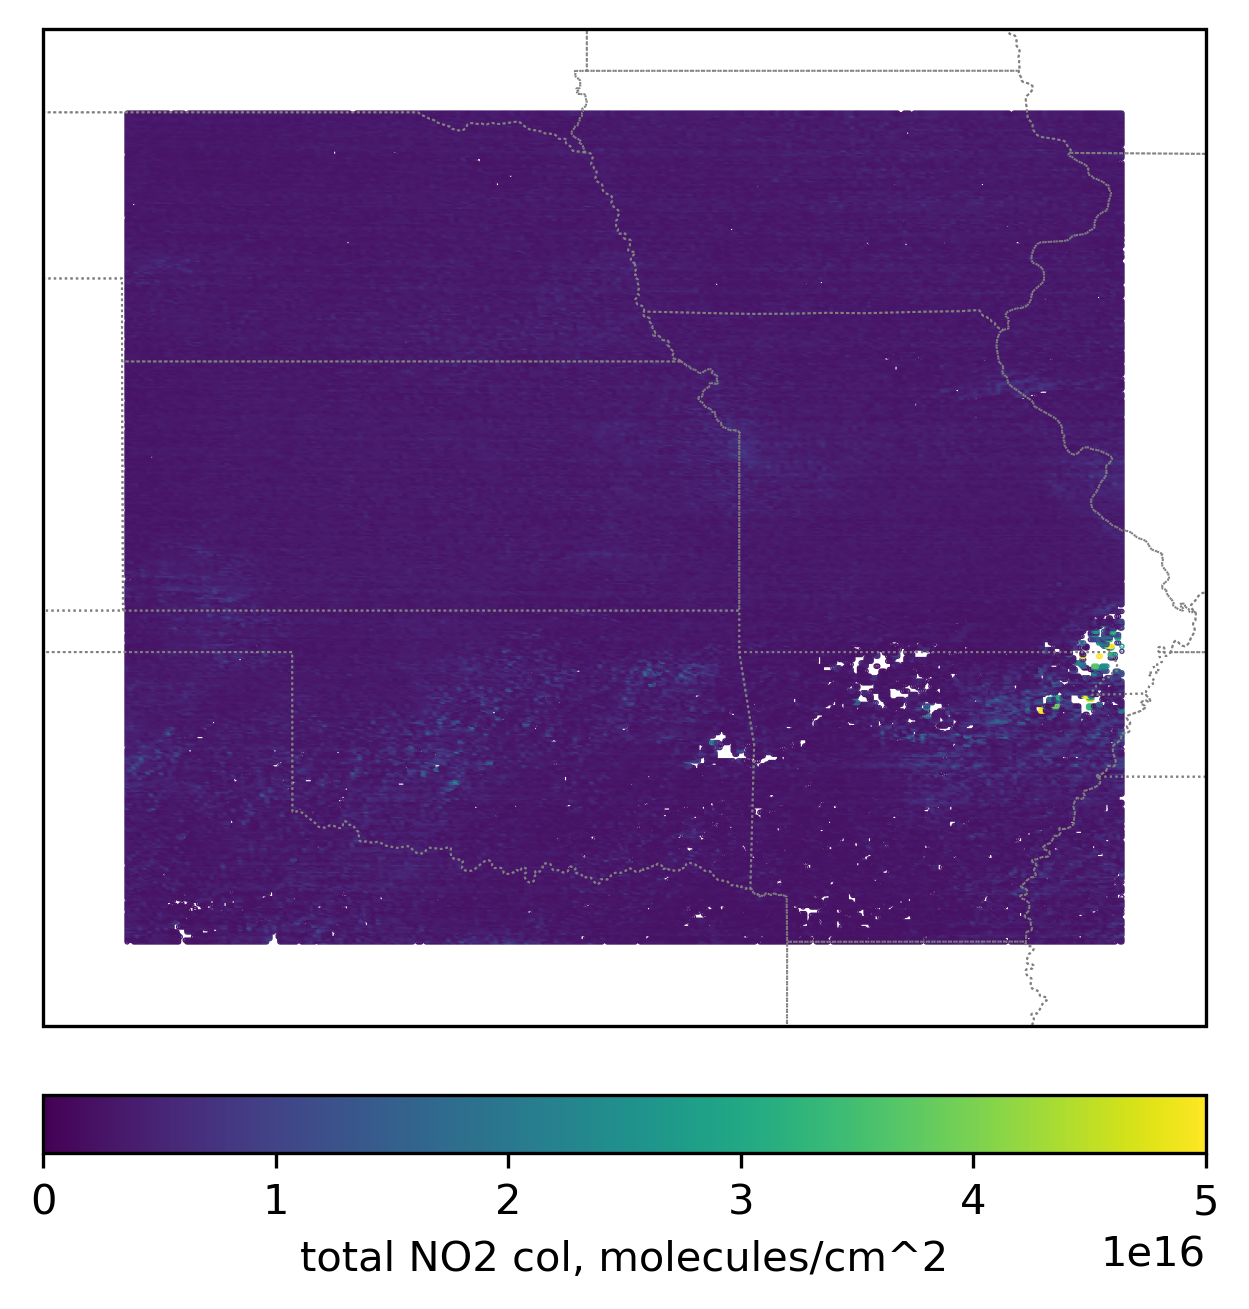

In [32]:
# Create a Cartopy projection
proj = ccrs.PlateCarree()
transform = ccrs.PlateCarree()

# Create a figure and axis.
fig, ax = plt.subplots(
    1, 1, figsize=(5, 6), dpi=300, facecolor=None, subplot_kw={"projection": proj}
)

# Add coastlines and U.S. state borders
ax.coastlines(linewidth=0.5)
ax.add_feature(cfeature.STATES, linestyle=":", edgecolor="gray", linewidth=0.5)

im = ax.scatter(
    lon_loc_2D[best_data_mask_loc],
    lat_loc_2D[best_data_mask_loc],
    s=0.1,
    c=trop_NO2_column_loc[best_data_mask_loc] + strat_NO2_column_loc[best_data_mask_loc],
    vmin=0,
    vmax=5.0e16,
    transform=transform,
)
ax.set_extent([-103, -89, 32, 44], crs=transform)

cb = plt.colorbar(
    im,
    ticks=[0, 1.0e16, 2.0e16, 3.0e16, 4.0e16, 5.0e16],
    location="bottom",
    fraction=0.05,
    pad=0.05,
)
cb.set_label("total NO2 col, " + NO2_unit, fontsize=10)

plt.show()